In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

## Basic score distribution visuals 


In [23]:
df = pd.read_parquet('../data/processed/merged.parquet')
df.shape

(15170, 6)

In [24]:
df.head(5)

,submission_id,score,split,part,score_overall,audio_files
0,SI114J-00011,5.0,dev,P1,5.250,[ml\data\raw\data\dev\dev01\SI114J-00011-P1000...
1,SI114J-00045,4.0,dev,P1,3.750,[ml\data\raw\data\dev\dev01\SI114J-00045-P1000...
2,SI114J-00057,3.5,dev,P1,3.625,[ml\data\raw\data\dev\dev01\SI114J-00057-P1000...
3,SI114J-00116,3.0,dev,P1,3.375,[ml\data\raw\data\dev\dev02\SI114J-00116-P1000...
4,SI114J-00139,4.0,dev,P1,3.500,[ml\data\raw\data\dev\dev02\SI114J-00139-P1000...


In [25]:
df['audio_counts'] = df['audio_files'].str.len()

### Split Dev and Train to get overview of what we have

In [26]:
dev_df = df[df['split'] == 'dev']
train_df = df[df['split'] == 'train']

dev_df.shape, train_df.shape

((1752, 7), (12218, 7))

#### 1. Count, median, standard deviation, min/max, and frequency of every score—separately for Train and Dev.

In [ ]:
dev_df.groupby('part').agg(
    score_count=('score', 'count'),
    score_sum=('score', 'sum'),
    score_std=('score', 'std'),
    score_mean=('score', 'mean'),
    score_max=('score', 'max'),
    score_min=('score', 'min'),
)

,score_count,score_sum,score_std,score_mean,score_max,score_min
part,,,,,,
P1,438,1683.5,0.780244,3.843607,5.5,2.0
P3,438,1765.5,0.731498,4.030822,5.5,2.0
P4,438,1692.0,0.727493,3.863014,5.5,2.0
P5,438,1703.0,0.748787,3.888128,5.5,2.0


In [28]:
train_df.groupby('part').agg(
    score_count=('score', 'count'),
    score_sum=('score', 'sum'),
    score_std=('score', 'std'),
    score_mean=('score', 'mean'),
    score_max=('score', 'max'),
    score_min=('score', 'min'),
)

,score_count,score_sum,score_std,score_mean,score_max,score_min
part,,,,,,
P1,3068,12128.0,0.726494,3.953064,5.5,2.0
P3,3060,12655.0,0.691615,4.135621,5.5,2.0
P4,3005,11601.5,0.755906,3.860732,5.5,2.0
P5,3085,12151.0,0.706171,3.938736,5.5,2.0


#### Audio duration

In [32]:
import os

from tqdm.notebook import tqdm

os.getcwd()

tqdm.pandas()

ROOT = r'c:\work_dir\SpeakTrace'

dev_df['duration_sec'] = dev_df['audio_files'].progress_apply(
    lambda paths: sum(sf.info(os.path.join(ROOT, p)).duration for p in paths)
)

train_df['duration_sec'] = train_df['audio_files'].progress_apply(
    lambda paths: sum(sf.info(os.path.join(ROOT, p)).duration for p in paths)
)

  0%|          | 0/1752 [00:00<?, ?it/s]

C:\Users\CBABM\AppData\Local\Temp\ipykernel_2164\1306312888.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_df['duration_sec'] = dev_df['audio_files'].progress_apply(


  0%|          | 0/12218 [00:00<?, ?it/s]

C:\Users\CBABM\AppData\Local\Temp\ipykernel_2164\1306312888.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['duration_sec'] = train_df['audio_files'].progress_apply(


In [36]:
dev_df.groupby('part').agg(
    duration_sec_count=('duration_sec', 'count'),
    duration_sec_sum=('duration_sec', 'sum'),
    duration_sec_std=('duration_sec', 'std'),
    duration_sec_mean=('duration_sec', 'mean'),
    duration_sec_max=('duration_sec', 'max'),
    duration_sec_min=('duration_sec', 'min'),
)

,duration_sec_count,duration_sec_sum,duration_sec_std,duration_sec_mean,duration_sec_max,duration_sec_min
part,,,,,,
P1,438,36610.668312,20.935978,83.586001,105.13450,16.38000
P3,438,24374.001062,7.824028,55.648404,61.48325,7.61575
P4,438,24325.504313,7.483754,55.537681,61.29750,5.12000
P5,438,41587.359250,10.171193,94.948309,108.66375,30.71250


In [35]:
train_df.groupby('part').agg(
    duration_sec_count=('duration_sec', 'count'),
    duration_sec_sum=('duration_sec', 'sum'),
    duration_sec_std=('duration_sec', 'std'),
    duration_sec_mean=('duration_sec', 'mean'),
    duration_sec_max=('duration_sec', 'max'),
    duration_sec_min=('duration_sec', 'min'),
)

,duration_sec_count,duration_sec_sum,duration_sec_std,duration_sec_mean,duration_sec_max,duration_sec_min
part,,,,,,
P1,3068,253146.761313,20.318616,82.511982,107.735000,5.971875
P3,3060,169279.874937,7.895785,55.320221,70.809375,3.753750
P4,3005,163641.080500,8.340676,54.456266,69.615000,10.216250
P5,3085,293027.530375,9.494162,94.984613,107.493750,18.946500


### Plots

In [37]:
# --- shared plot style: colorblind-safe palette, consistent split colors ---
from matplotlib.colors import LinearSegmentedColormap

COL = {'train': '#2a78d6', 'dev': '#eb6834', 'eval': '#1baf7a'}   # fixed: split -> hue
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
BLUES = LinearSegmentedColormap.from_list('sla_blues', ['#cde2fb', '#3987e5', '#0d366b'])
PARTS = ['P1', 'P3', 'P4', 'P5']

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'text.color': INK, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'font.size': 10, 'axes.titlesize': 11, 'legend.frameon': False,
})

td = pd.concat([train_df, dev_df])   # the two scored splits, with duration_sec computed

#### 1. Dataset size: submission-parts per split × part

All splits are balanced across parts; train is roughly 7× dev, and eval (unscored for us) is the smallest.

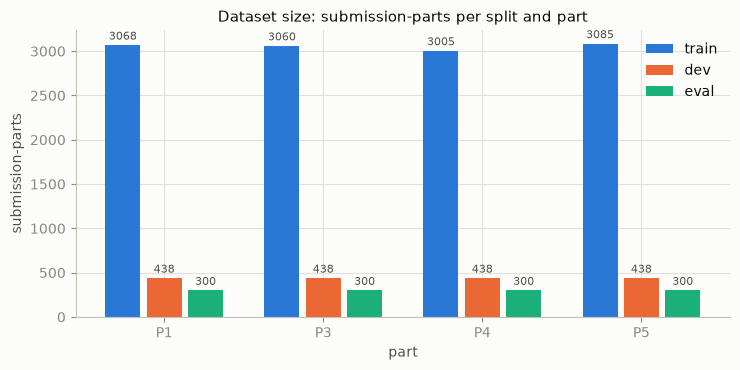

In [39]:
sizes = df.pivot_table(index='part', columns='split', values='submission_id', aggfunc='count')
order = [s for s in ['train', 'dev', 'eval'] if s in sizes.columns]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = np.arange(len(sizes.index))
w = 0.26
for i, split in enumerate(order):
    bars = ax.bar(x + (i - 1) * w, sizes[split], width=w - 0.04, color=COL[split], label=split)
    ax.bar_label(bars, fontsize=8, color=INK2, padding=2)

ax.set_xticks(x, sizes.index)
ax.set_xlabel('part')
ax.set_ylabel('submission-parts')
ax.set_title('Dataset size: submission-parts per split and part')
ax.legend()
plt.tight_layout()
plt.show()

#### 2. Score distribution — train vs dev (with median), frequency of every score value

Shares are normalized per split because train is ~7× dev. If the orange and blue bars track each other, dev is a faithful miniature of train and dev metrics will transfer.

count  median   mean    std  min  max
split part                                       
dev   P1      438     4.0  3.844  0.780  2.0  5.5
      P3      438     4.0  4.031  0.731  2.0  5.5
      P4      438     4.0  3.863  0.727  2.0  5.5
      P5      438     4.0  3.888  0.749  2.0  5.5
train P1     3068     4.0  3.953  0.726  2.0  5.5
      P3     3060     4.0  4.136  0.692  2.0  5.5
      P4     3005     4.0  3.861  0.756  2.0  5.5
      P5     3085     4.0  3.939  0.706  2.0  5.5

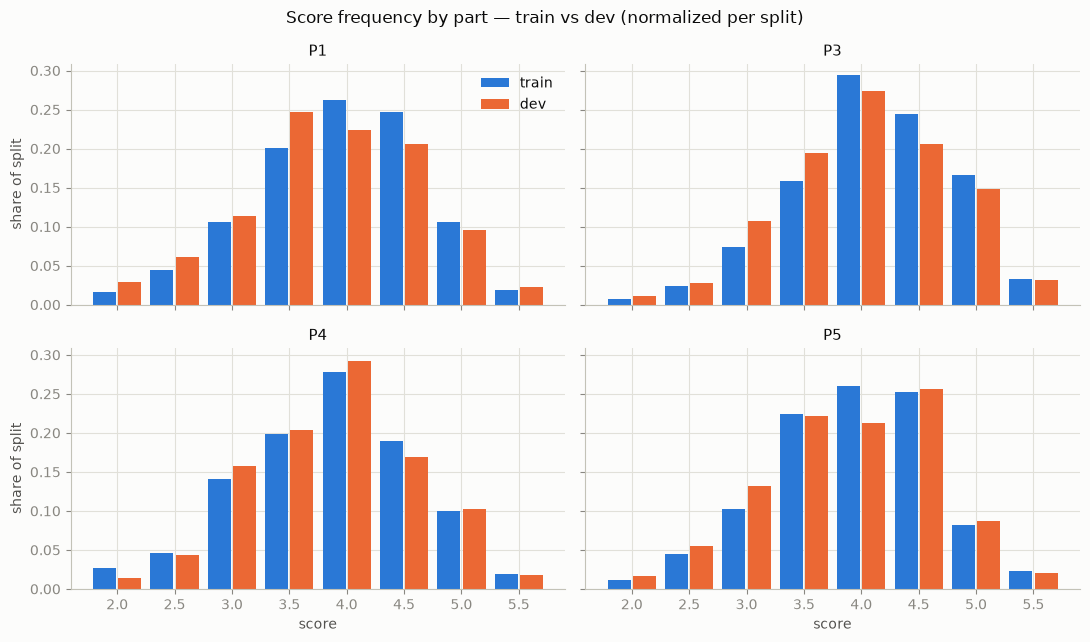

In [40]:
stats = (td.groupby(['split', 'part'])['score']
           .agg(['count', 'median', 'mean', 'std', 'min', 'max']).round(3))
display(stats)

score_vals = np.sort(td['score'].dropna().unique())
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True, sharey=True)
for ax, part in zip(axes.flat, PARTS):
    for i, split in enumerate(['train', 'dev']):
        s = (td.loc[(td['split'] == split) & (td['part'] == part), 'score']
               .value_counts(normalize=True).reindex(score_vals, fill_value=0))
        ax.bar(s.index + (i - 0.5) * 0.22, s.values, width=0.20, color=COL[split], label=split)
    ax.set_title(part)
    ax.set_xticks(score_vals)
for ax in axes[-1]:
    ax.set_xlabel('score')
for ax in axes[:, 0]:
    ax.set_ylabel('share of split')
axes[0, 0].legend()
fig.suptitle('Score frequency by part — train vs dev (normalized per split)')
plt.tight_layout()
plt.show()

#### 3. Recordings per submission-part

No rows have zero audio. Structure differs by part: P3/P4 are always a single recording, P5 is almost always five, and P1 is usually six shorter clips (the interview questions) — the rare P1 rows with fewer clips are partially answered interviews.

rows with zero or missing audio: 0


audio_counts,1,2,3,4,5,6
part,,,,,,
P1,1,4,12,74,184,3231
P3,3498,0,0,0,0,0
P4,3443,0,0,0,0,0
P5,2,5,13,48,3455,0


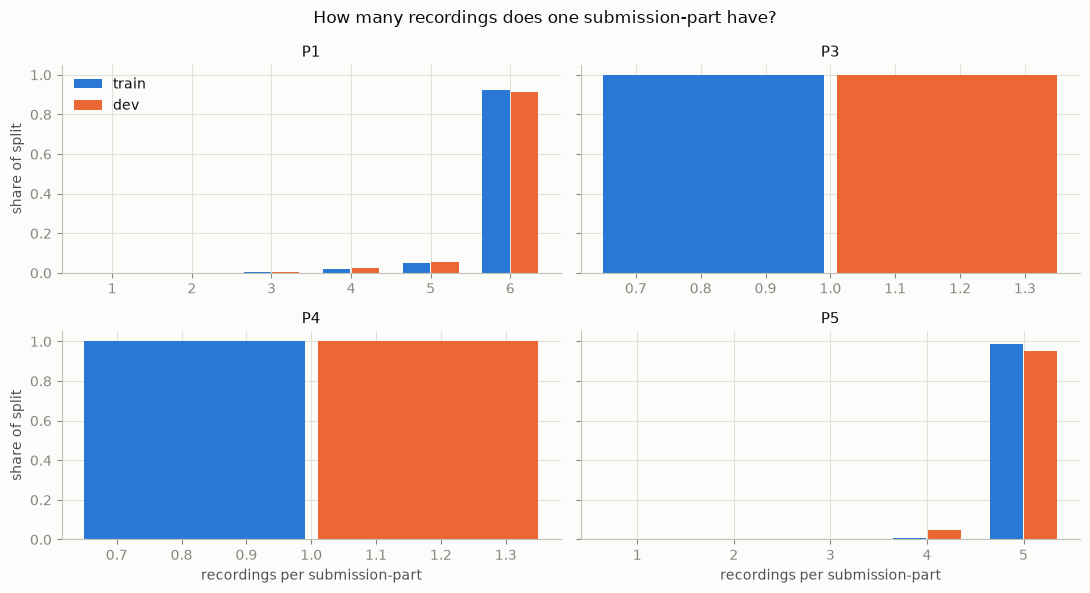

unusually many recordings (> p99 = 6):


,submission_id,split,part,audio_counts,score


In [41]:
print('rows with zero or missing audio:', int((td['audio_counts'].fillna(0) == 0).sum()))
display(pd.crosstab(td['part'], td['audio_counts']))

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey=True)
for ax, part in zip(axes.flat, PARTS):
    for i, split in enumerate(['train', 'dev']):
        s = (td.loc[(td['split'] == split) & (td['part'] == part), 'audio_counts']
               .value_counts(normalize=True).sort_index())
        ax.bar(s.index + (i - 0.5) * 0.36, s.values, width=0.34, color=COL[split], label=split)
    ax.set_title(part)
for ax in axes[-1]:
    ax.set_xlabel('recordings per submission-part')
for ax in axes[:, 0]:
    ax.set_ylabel('share of split')
axes[0, 0].legend()
fig.suptitle('How many recordings does one submission-part have?')
plt.tight_layout()
plt.show()

hi_cut = td['audio_counts'].quantile(0.99)
print(f'unusually many recordings (> p99 = {hi_cut:.0f}):')
display(td[td['audio_counts'] > hi_cut]
        [['submission_id', 'split', 'part', 'audio_counts', 'score']]
        .sort_values('audio_counts', ascending=False).head(10))

#### 4. Audio duration: totals per submission-part and individual recordings

Total speaking time clusters near a per-part ceiling (~100s for P1/P5, ~60s for P3/P4) — the long left tails are candidates for truncated or abandoned attempts. Individually: P3/P4 are one continuous ~55s recording, P1 is up to six clips of varied length, P5 is five ~20s clips.

In [42]:
# per-recording durations, cached to parquet so re-runs are instant
CACHE = '../data/processed/file_durations.parquet'

if os.path.exists(CACHE):
    file_dur = pd.read_parquet(CACHE)
else:
    rows = []
    sub = td[['submission_id', 'split', 'part', 'score', 'audio_files']]
    for sid, split, part, score, paths in tqdm(sub.itertuples(index=False), total=len(sub)):
        for p in paths:
            rows.append({'submission_id': sid, 'split': split, 'part': part, 'score': score,
                         'path': p, 'duration': sf.info(os.path.join(ROOT, p)).duration})
    file_dur = pd.DataFrame(rows)
    file_dur.to_parquet(CACHE)

print(f'{len(file_dur):,} individual recordings')
file_dur.groupby('part')['duration'].describe().round(2)

45,106 individual recordings


,count,mean,std,min,25%,50%,75%,max
part,,,,,,,,
P1,20647.0,14.03,5.99,1.36,9.47,16.38,19.96,26.38
P3,3498.0,55.36,7.89,3.75,54.43,59.04,59.89,70.81
P4,3443.0,54.59,8.24,5.12,52.38,58.70,59.89,69.61
P5,17518.0,19.10,2.06,3.92,19.28,19.96,19.96,24.40


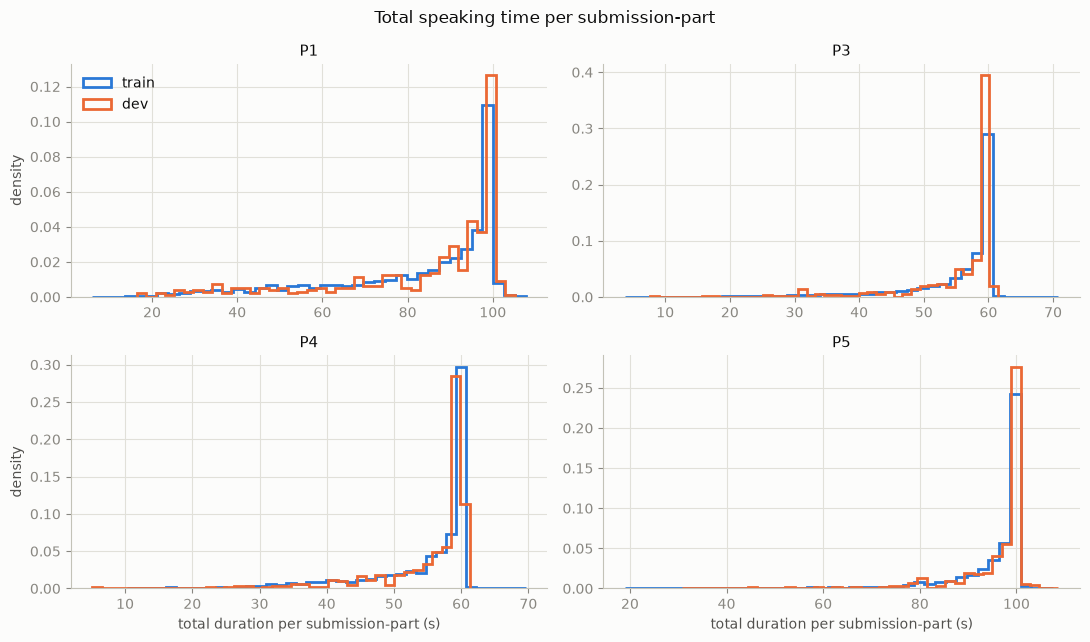

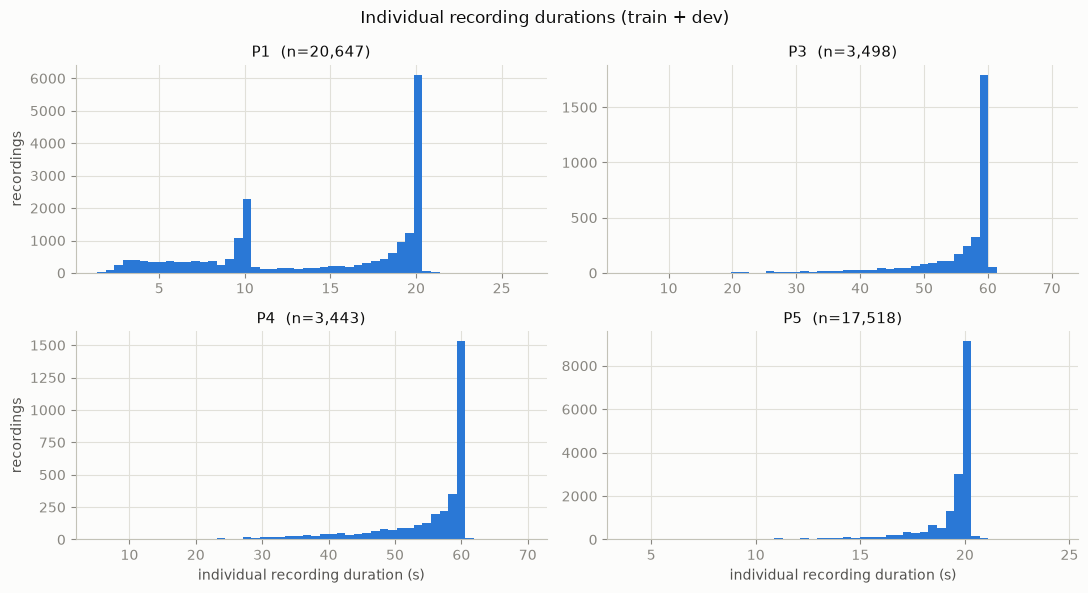

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for ax, part in zip(axes.flat, PARTS):
    for split in ['train', 'dev']:
        vals = td.loc[(td['split'] == split) & (td['part'] == part), 'duration_sec'].dropna()
        ax.hist(vals, bins=40, density=True, histtype='step', linewidth=2,
                color=COL[split], label=split)
    ax.set_title(part)
for ax in axes[-1]:
    ax.set_xlabel('total duration per submission-part (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('density')
axes[0, 0].legend()
fig.suptitle('Total speaking time per submission-part')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, part in zip(axes.flat, PARTS):
    vals = file_dur.loc[file_dur['part'] == part, 'duration']
    ax.hist(vals, bins=50, color=COL['train'])
    ax.set_title(f'{part}  (n={len(vals):,})')
for ax in axes[-1]:
    ax.set_xlabel('individual recording duration (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('recordings')
fig.suptitle('Individual recording durations (train + dev)')
plt.tight_layout()
plt.show()

#### 5. Missing coverage

Absent audio, missing part scores, missing overall scores, and submissions that don't have all 4 parts. Only train is affected: ~54% of its rows lack `score_overall`, and thousands of train submissions contributed only 1–3 parts.

,no_audio,no_part_score,no_overall,rows
split,,,,
dev,0,0,0,1752
eval,0,0,0,1200
train,0,0,6559,12218


incomplete submissions (fewer than 4 parts): 5395


submissions
split n_parts             
train 1               3991
      2                973
      3                431

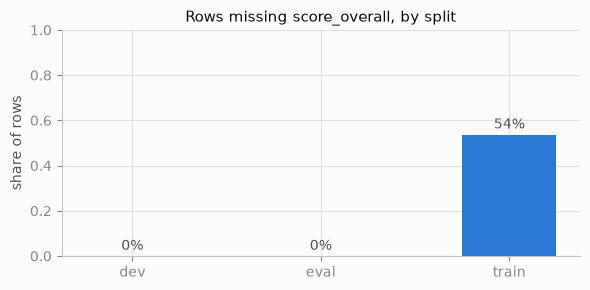

In [44]:
cov = df.assign(
    no_audio=df['audio_files'].isna() | (df['audio_counts'].fillna(0) == 0),
    no_part_score=df['score'].isna(),
    no_overall=df['score_overall'].isna(),
).groupby('split')[['no_audio', 'no_part_score', 'no_overall']].sum()
cov['rows'] = df.groupby('split').size()
display(cov)

parts_per = df.groupby(['split', 'submission_id'])['part'].nunique()
incomplete = parts_per[parts_per < 4]
print(f'incomplete submissions (fewer than 4 parts): {len(incomplete)}')
if len(incomplete):
    display(incomplete.rename('n_parts').reset_index()
            .groupby(['split', 'n_parts']).size().rename('submissions').to_frame())

share = cov['no_overall'] / cov['rows']
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(share.index, share.values, width=0.5, color=[COL[s] for s in share.index])
ax.bar_label(bars, fmt='{:.0%}', color=INK2, padding=2)
ax.set_ylim(0, 1)
ax.set_ylabel('share of rows')
ax.set_title('Rows missing score_overall, by split')
plt.tight_layout()
plt.show()

#### 6. Label consistency: does the mean of P1/P3/P4/P5 equal `score_overall`?

If agreement is exact, `score_overall` is derived (not an independent judgment) — meaning a model that predicts the four part scores gets the overall score for free.

1,685 submissions have all 4 part scores + an overall score
exact agreement (mean of parts == overall): 100.0%
max |part mean - overall|: 0.000


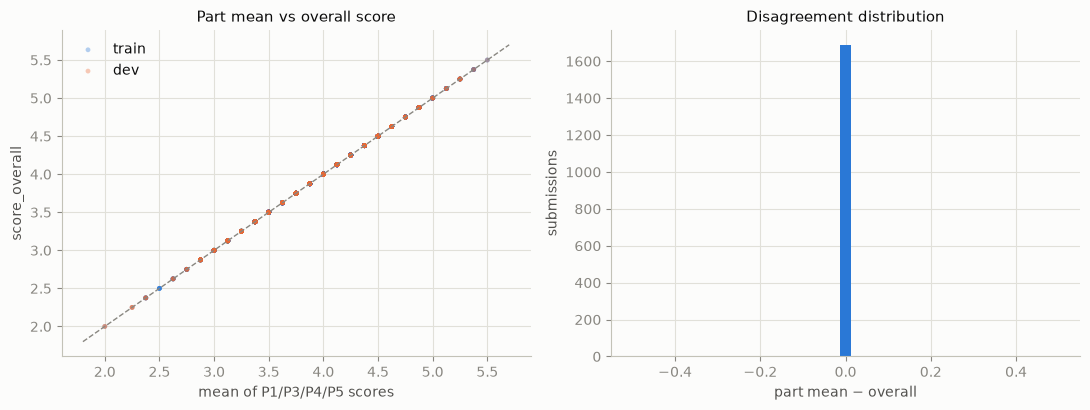

In [45]:
wide = td.pivot_table(index=['split', 'submission_id'], columns='part', values='score')
overall = td.groupby(['split', 'submission_id'])['score_overall'].first()
wide = wide.join(overall).dropna(subset=PARTS + ['score_overall'])
wide['part_mean'] = wide[PARTS].mean(axis=1)
wide['diff'] = wide['part_mean'] - wide['score_overall']

print(f'{len(wide):,} submissions have all 4 part scores + an overall score')
print(f'exact agreement (mean of parts == overall): {(wide["diff"].abs() < 1e-9).mean():.1%}')
print(f'max |part mean - overall|: {wide["diff"].abs().max():.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for split in ['train', 'dev']:
    d = wide.loc[split]
    ax1.scatter(d['part_mean'], d['score_overall'], s=12, alpha=0.35,
                color=COL[split], label=split, edgecolors='none')
lims = [wide[['part_mean', 'score_overall']].min().min() - 0.2,
        wide[['part_mean', 'score_overall']].max().max() + 0.2]
ax1.plot(lims, lims, color=MUTED, linewidth=1, linestyle='--')
ax1.set_xlabel('mean of P1/P3/P4/P5 scores')
ax1.set_ylabel('score_overall')
ax1.set_title('Part mean vs overall score')
ax1.legend()

ax2.hist(wide['diff'], bins=41, color=COL['train'])
ax2.set_xlabel('part mean − overall')
ax2.set_ylabel('submissions')
ax2.set_title('Disagreement distribution')
plt.tight_layout()
plt.show()

#### 7. Relationships: duration & recording count vs score; part scores vs overall

Duration correlates with score most strongly in P1 (r ≈ 0.48) — weak speakers give short answers to the interview questions. For P3–P5 the recording fills a fixed time window, so the signal is weaker. The heatmap shows how interchangeable the part scores are as predictors of the overall score.

Pearson correlation with the part score (NaN = count never varies):


,duration_vs_score,count_vs_score
P1,0.480,0.200
P3,0.288,NaN
P4,0.241,NaN
P5,0.235,0.138


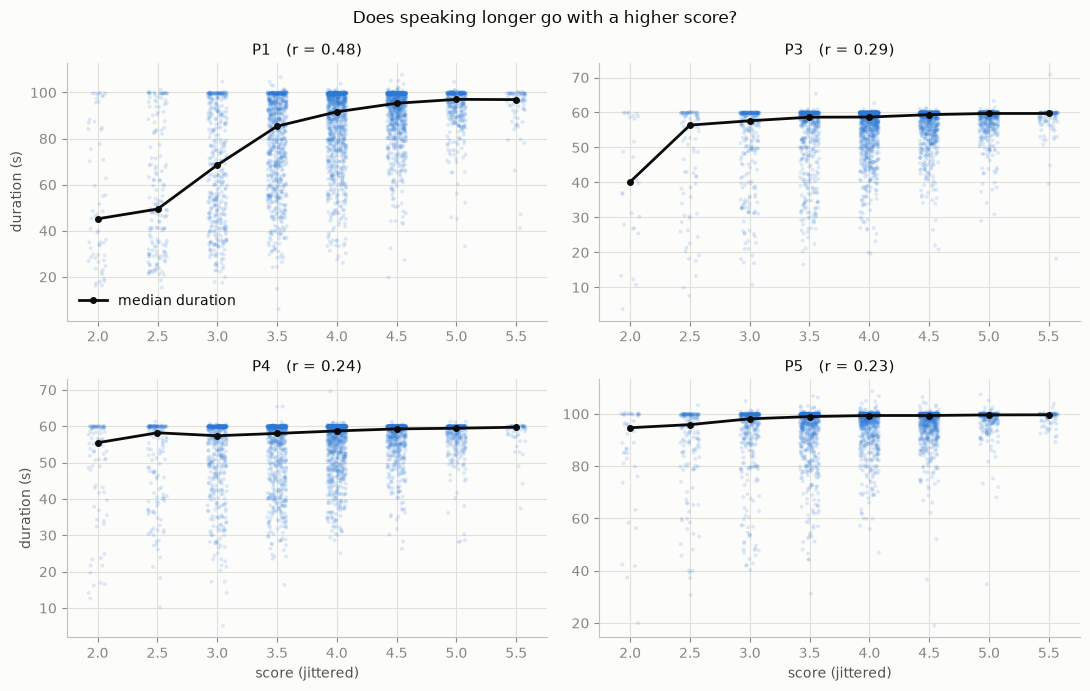

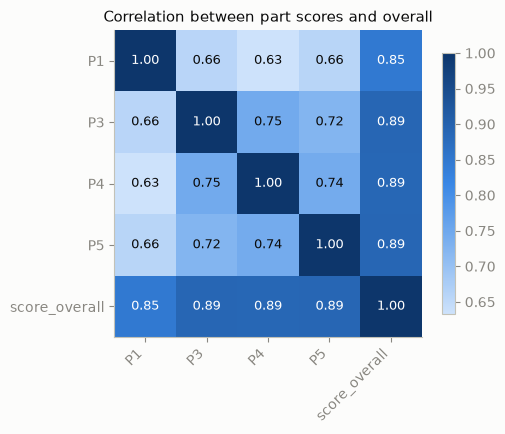

In [46]:
rel = pd.DataFrame({
    part: {
        'duration_vs_score': d['score'].corr(d['duration_sec']),
        'count_vs_score': (d['score'].corr(d['audio_counts'])
                           if d['audio_counts'].nunique() > 1 else np.nan),
    }
    for part, d in td.groupby('part')
}).T.round(3)
print('Pearson correlation with the part score (NaN = count never varies):')
display(rel)

rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, part in zip(axes.flat, PARTS):
    d = td[td['part'] == part].dropna(subset=['score', 'duration_sec'])
    ax.scatter(d['score'] + rng.uniform(-0.08, 0.08, len(d)), d['duration_sec'],
               s=8, alpha=0.15, color=COL['train'], edgecolors='none')
    med = d.groupby('score')['duration_sec'].median()
    ax.plot(med.index, med.values, color=INK, linewidth=2, marker='o', markersize=4,
            label='median duration')
    ax.set_title(f'{part}   (r = {d["score"].corr(d["duration_sec"]):.2f})')
for ax in axes[-1]:
    ax.set_xlabel('score (jittered)')
for ax in axes[:, 0]:
    ax.set_ylabel('duration (s)')
axes[0, 0].legend()
fig.suptitle('Does speaking longer go with a higher score?')
plt.tight_layout()
plt.show()

corr = wide[PARTS + ['score_overall']].corr()
vmin = corr.values.min()
fig, ax = plt.subplots(figsize=(5.4, 4.4))
im = ax.imshow(corr, cmap=BLUES, vmin=vmin, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.index)
mid = (vmin + 1) / 2
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if v > mid else INK)
ax.set_title('Correlation between part scores and overall')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

#### 8. Outlier inspection

A 3.8s submission-part or a 108s one are worth listening to — very short clips may be empty/failed recordings, and score-2.0 responses with long durations tell us the model can't rely on duration alone.

In [47]:
cols = ['submission_id', 'split', 'part', 'score', 'score_overall', 'audio_counts', 'duration_sec']
print('— shortest submission-parts —')
display(td.nsmallest(5, 'duration_sec')[cols])
print('— longest submission-parts —')
display(td.nlargest(5, 'duration_sec')[cols])
print('— lowest-scored —')
display(td.nsmallest(5, 'score')[cols])
print('— highest-scored —')
display(td.nlargest(5, 'score')[cols])

— shortest submission-parts —


,submission_id,split,part,score,score_overall,audio_counts,duration_sec
8491,SI141B-01182,train,P3,2.0,NaN,1,3.753750
877,SI114J-00045,dev,P4,3.0,3.75,1,5.120000
4248,SI12BD-00231,train,P1,3.5,NaN,1,5.971875
631,SI12BD-00080,dev,P3,2.5,4.00,1,7.615750
7420,SI128D-00081,train,P3,2.5,NaN,1,9.896250


— longest submission-parts —


,submission_id,split,part,score,score_overall,audio_counts,duration_sec
1422,SI127E-00262,dev,P5,4.0,3.75,5,108.66375
3691,SI127E-00350,train,P1,4.5,NaN,6,107.73500
12091,SI114J-00024,train,P5,5.0,NaN,5,107.49375
12553,SI1267-00460,train,P5,3.5,NaN,5,106.81125
12923,SI127E-00911,train,P5,4.0,NaN,5,106.80625


— lowest-scored —


,submission_id,split,part,score,score_overall,audio_counts,duration_sec
3042,SI114J-00255,train,P1,2.0,2.875,6,62.790000
3057,SI114J-00290,train,P1,2.0,2.625,6,95.891250
3182,SI114J-00578,train,P1,2.0,2.000,6,84.630000
3200,SI114J-00628,train,P1,2.0,2.000,6,70.126875
3211,SI114J-00655,train,P1,2.0,3.125,6,98.791875


— highest-scored —


,submission_id,split,part,score,score_overall,audio_counts,duration_sec
2958,SI114J-00018,train,P1,5.5,NaN,6,99.986250
2964,SI114J-00046,train,P1,5.5,NaN,6,99.133125
2966,SI114J-00048,train,P1,5.5,NaN,6,47.092500
2996,SI114J-00138,train,P1,5.5,4.875,6,83.947500
3002,SI114J-00157,train,P1,5.5,5.375,6,99.645000


In [48]:
# listen to a suspicious case (change the row selection to inspect others)
from IPython.display import Audio

row = td.nsmallest(1, 'duration_sec').iloc[0]
print(row['submission_id'], row['part'], f"{row['duration_sec']:.1f}s, score {row['score']}")
Audio(os.path.join(ROOT, row['audio_files'][0]))

SI141B-01182 P3 3.8s, score 2.0
